In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

sys.path.append(os.path.abspath(".."))

from config import RFM_DATA_PATH

%matplotlib inline

In [3]:
df = pd.read_csv(RFM_DATA_PATH)
df.head()

,CustomerID,Recency,Frequency,Monetary,R,F,M,rfm_score,customer_segmentation
0,12346,326,1,77183.60,1,1,5,115,Standard Customer
1,12347,2,7,4310.00,5,5,5,555,VIP
2,12348,75,4,1797.24,2,4,4,244,At Risk
3,12349,19,1,1757.55,4,1,4,414,Standard Customer
4,12350,310,1,334.40,1,1,2,112,Hibernating


In [36]:
df.describe()

,CustomerID,Recency,Frequency,Monetary,R,F,M,rfm_score
count,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000,4338.00000,4338.00000,4338.000000
mean,15300.408022,92.536422,4.272015,2054.266460,3.015445,3.00000,3.00000,334.544491
std,1721.808492,100.014169,7.697998,8989.230441,1.414537,1.41454,1.41454,150.065231
min,12346.000000,1.000000,1.000000,3.750000,1.000000,1.00000,1.00000,111.000000
25%,13813.250000,18.000000,1.000000,307.415000,2.000000,2.00000,2.00000,221.000000
50%,15299.500000,51.000000,2.000000,674.485000,3.000000,3.00000,3.00000,333.000000
75%,16778.750000,142.000000,5.000000,1661.740000,4.000000,4.00000,4.00000,454.000000
max,18287.000000,374.000000,209.000000,280206.020000,5.000000,5.00000,5.00000,555.000000


In [40]:
df["log_recency"] = np.log1p(df["Recency"])
df["log_frequency"] = np.log1p(df["Frequency"])
df["log_monetary"] = np.log1p(df["Monetary"])

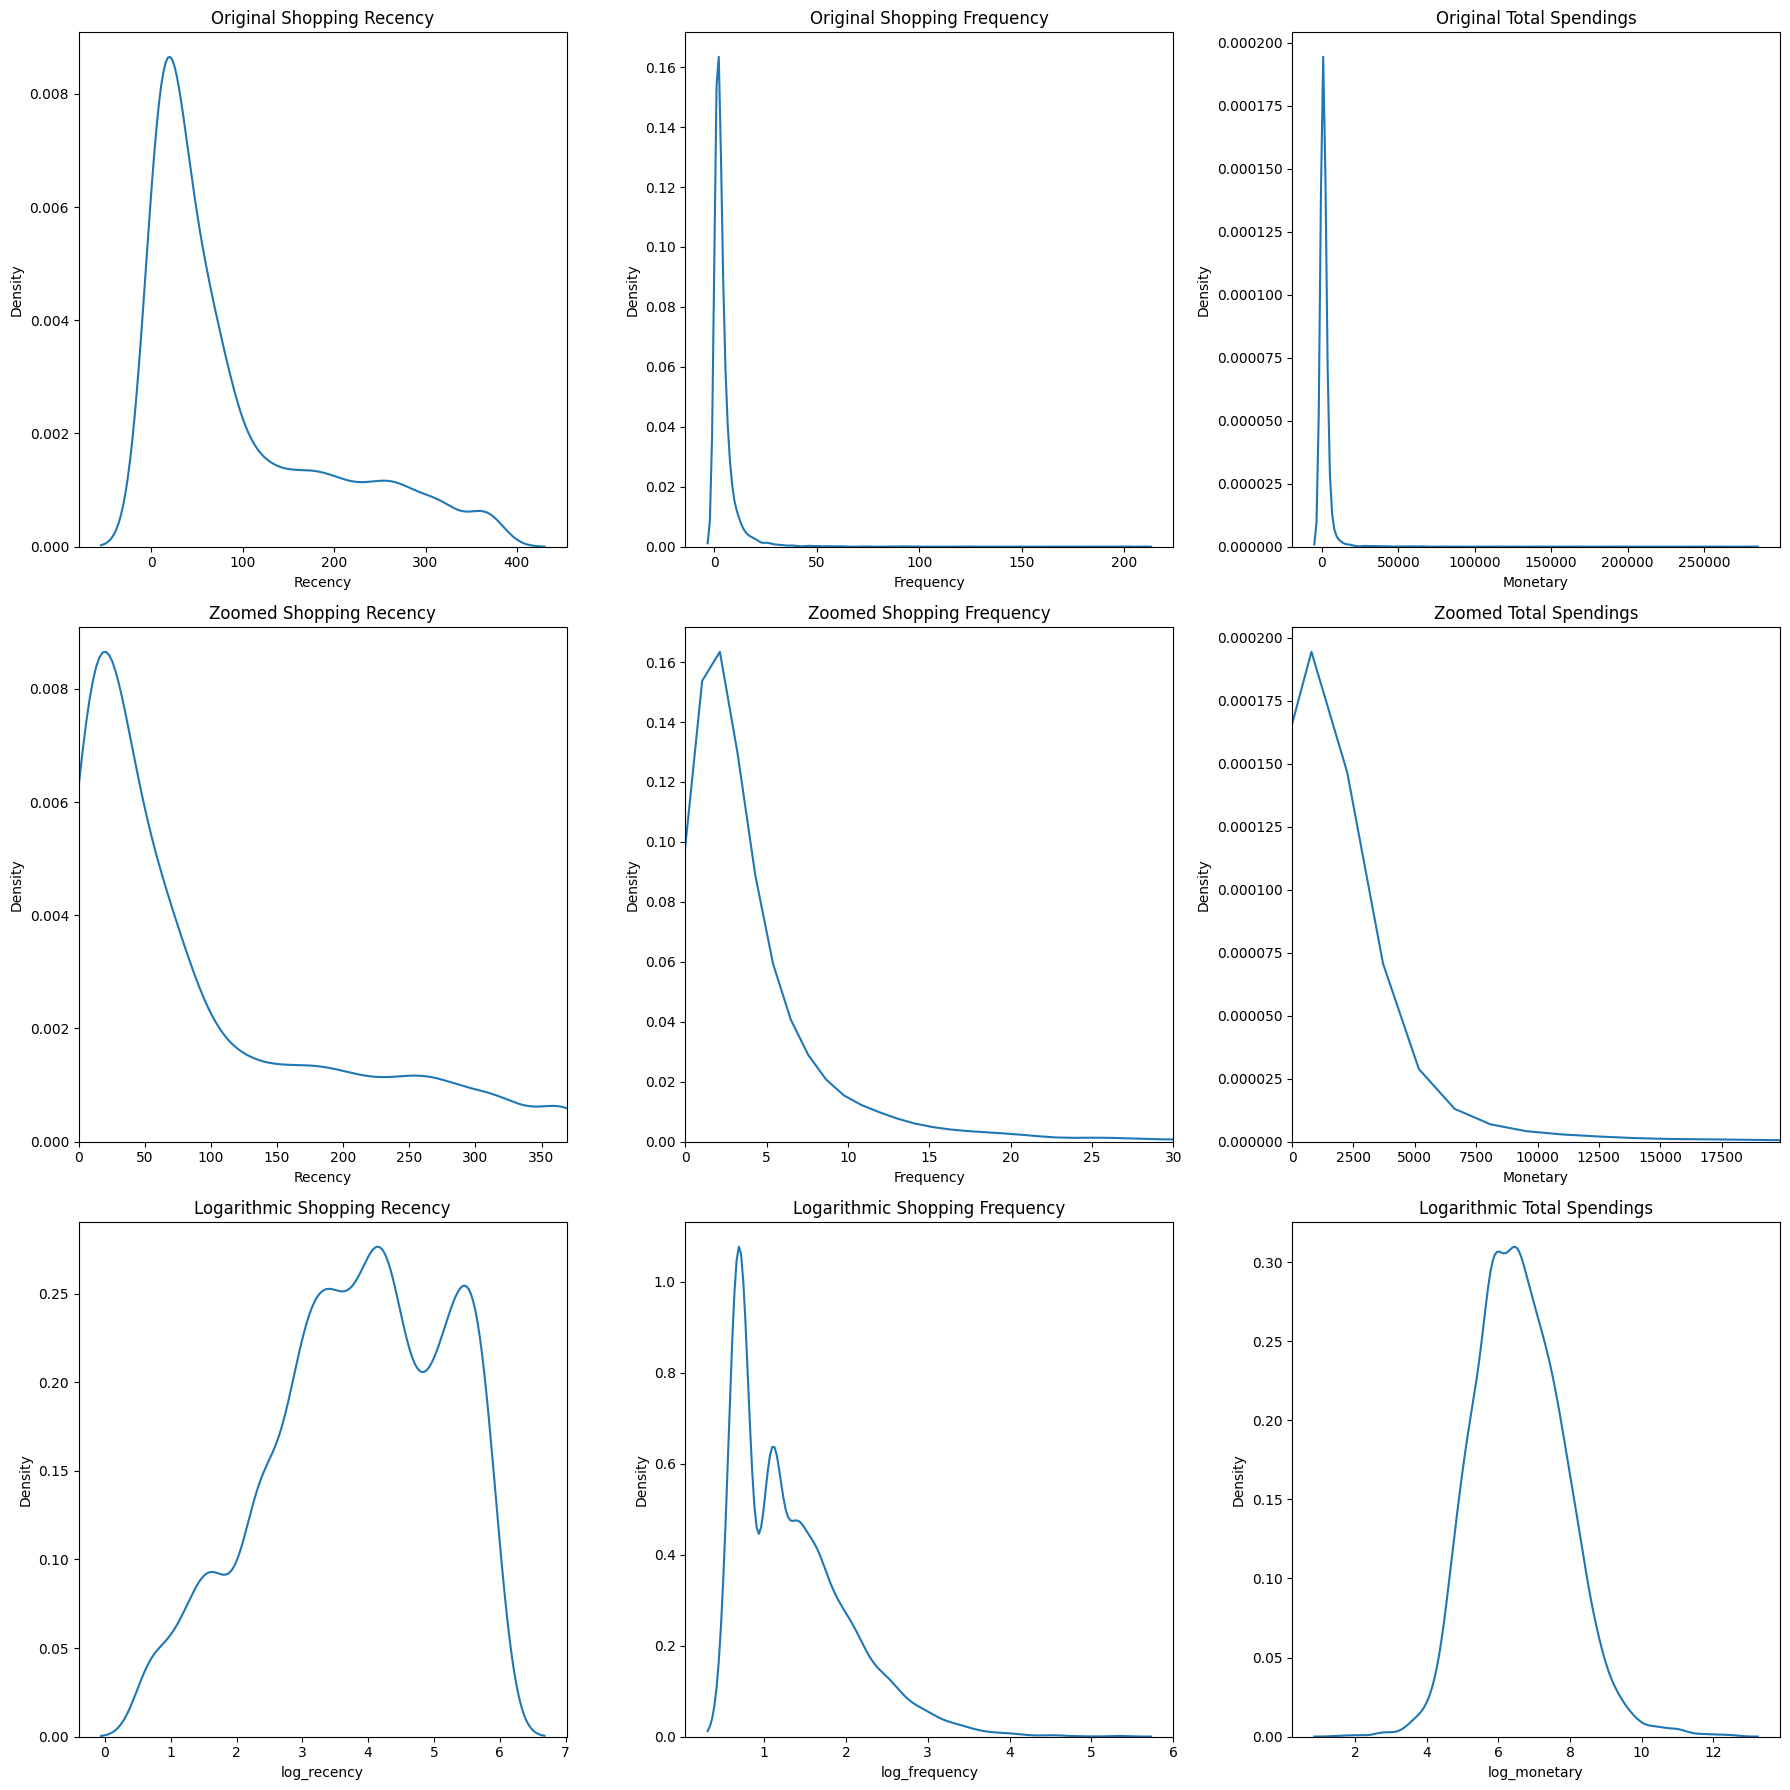

In [41]:
fig,axes = plt.subplots(3,3,figsize=(18,18))

sns.kdeplot(df["Recency"],ax=axes[0,0]).set_title("Original Shopping Recency")
sns.kdeplot(df["Frequency"],ax=axes[0,1]).set_title("Original Shopping Frequency")
sns.kdeplot(df["Monetary"],ax=axes[0,2]).set_title("Original Total Spendings")

sns.kdeplot(df["Recency"],ax=axes[1,0]).set_title("Zoomed Shopping Recency")
sns.kdeplot(df["Frequency"],ax=axes[1,1]).set_title("Zoomed Shopping Frequency")
sns.kdeplot(df["Monetary"],ax=axes[1,2]).set_title("Zoomed Total Spendings")

sns.kdeplot(df["log_recency"],ax=axes[2,0]).set_title("Logarithmic Shopping Recency")
sns.kdeplot(df["log_frequency"],ax=axes[2,1]).set_title("Logarithmic Shopping Frequency")
sns.kdeplot(df["log_monetary"],ax=axes[2,2]).set_title("Logarithmic Total Spendings")

axes[1,0].set_xlim(0,df["Recency"].quantile(0.99))
axes[1,1].set_xlim(0,df["Frequency"].quantile(0.99))
axes[1,2].set_xlim(0,df["Monetary"].quantile(0.99))



plt.tight_layout()
plt.show()

C:\Users\Tonmoy Saha\AppData\Local\Temp\ipykernel_42608\3084743188.py:4: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df,x="Frequency",hue="customer_segmentation",ax=axes[0,1]).set_title("Segmented Customer Frequency")
C:\Users\Tonmoy Saha\AppData\Local\Temp\ipykernel_42608\3084743188.py:8: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df,x="Frequency",hue="customer_segmentation",ax=axes[1,1]).set_title("Segmented Customer Frequency (Zoomed)")
C:\Users\Tonmoy Saha\AppData\Local\Temp\ipykernel_42608\3084743188.py:12: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df,x="log_frequency",hue="customer_segmentation",ax=axes[2,1]).set_title("Segmented Customer Frequency (Logarithmic)")


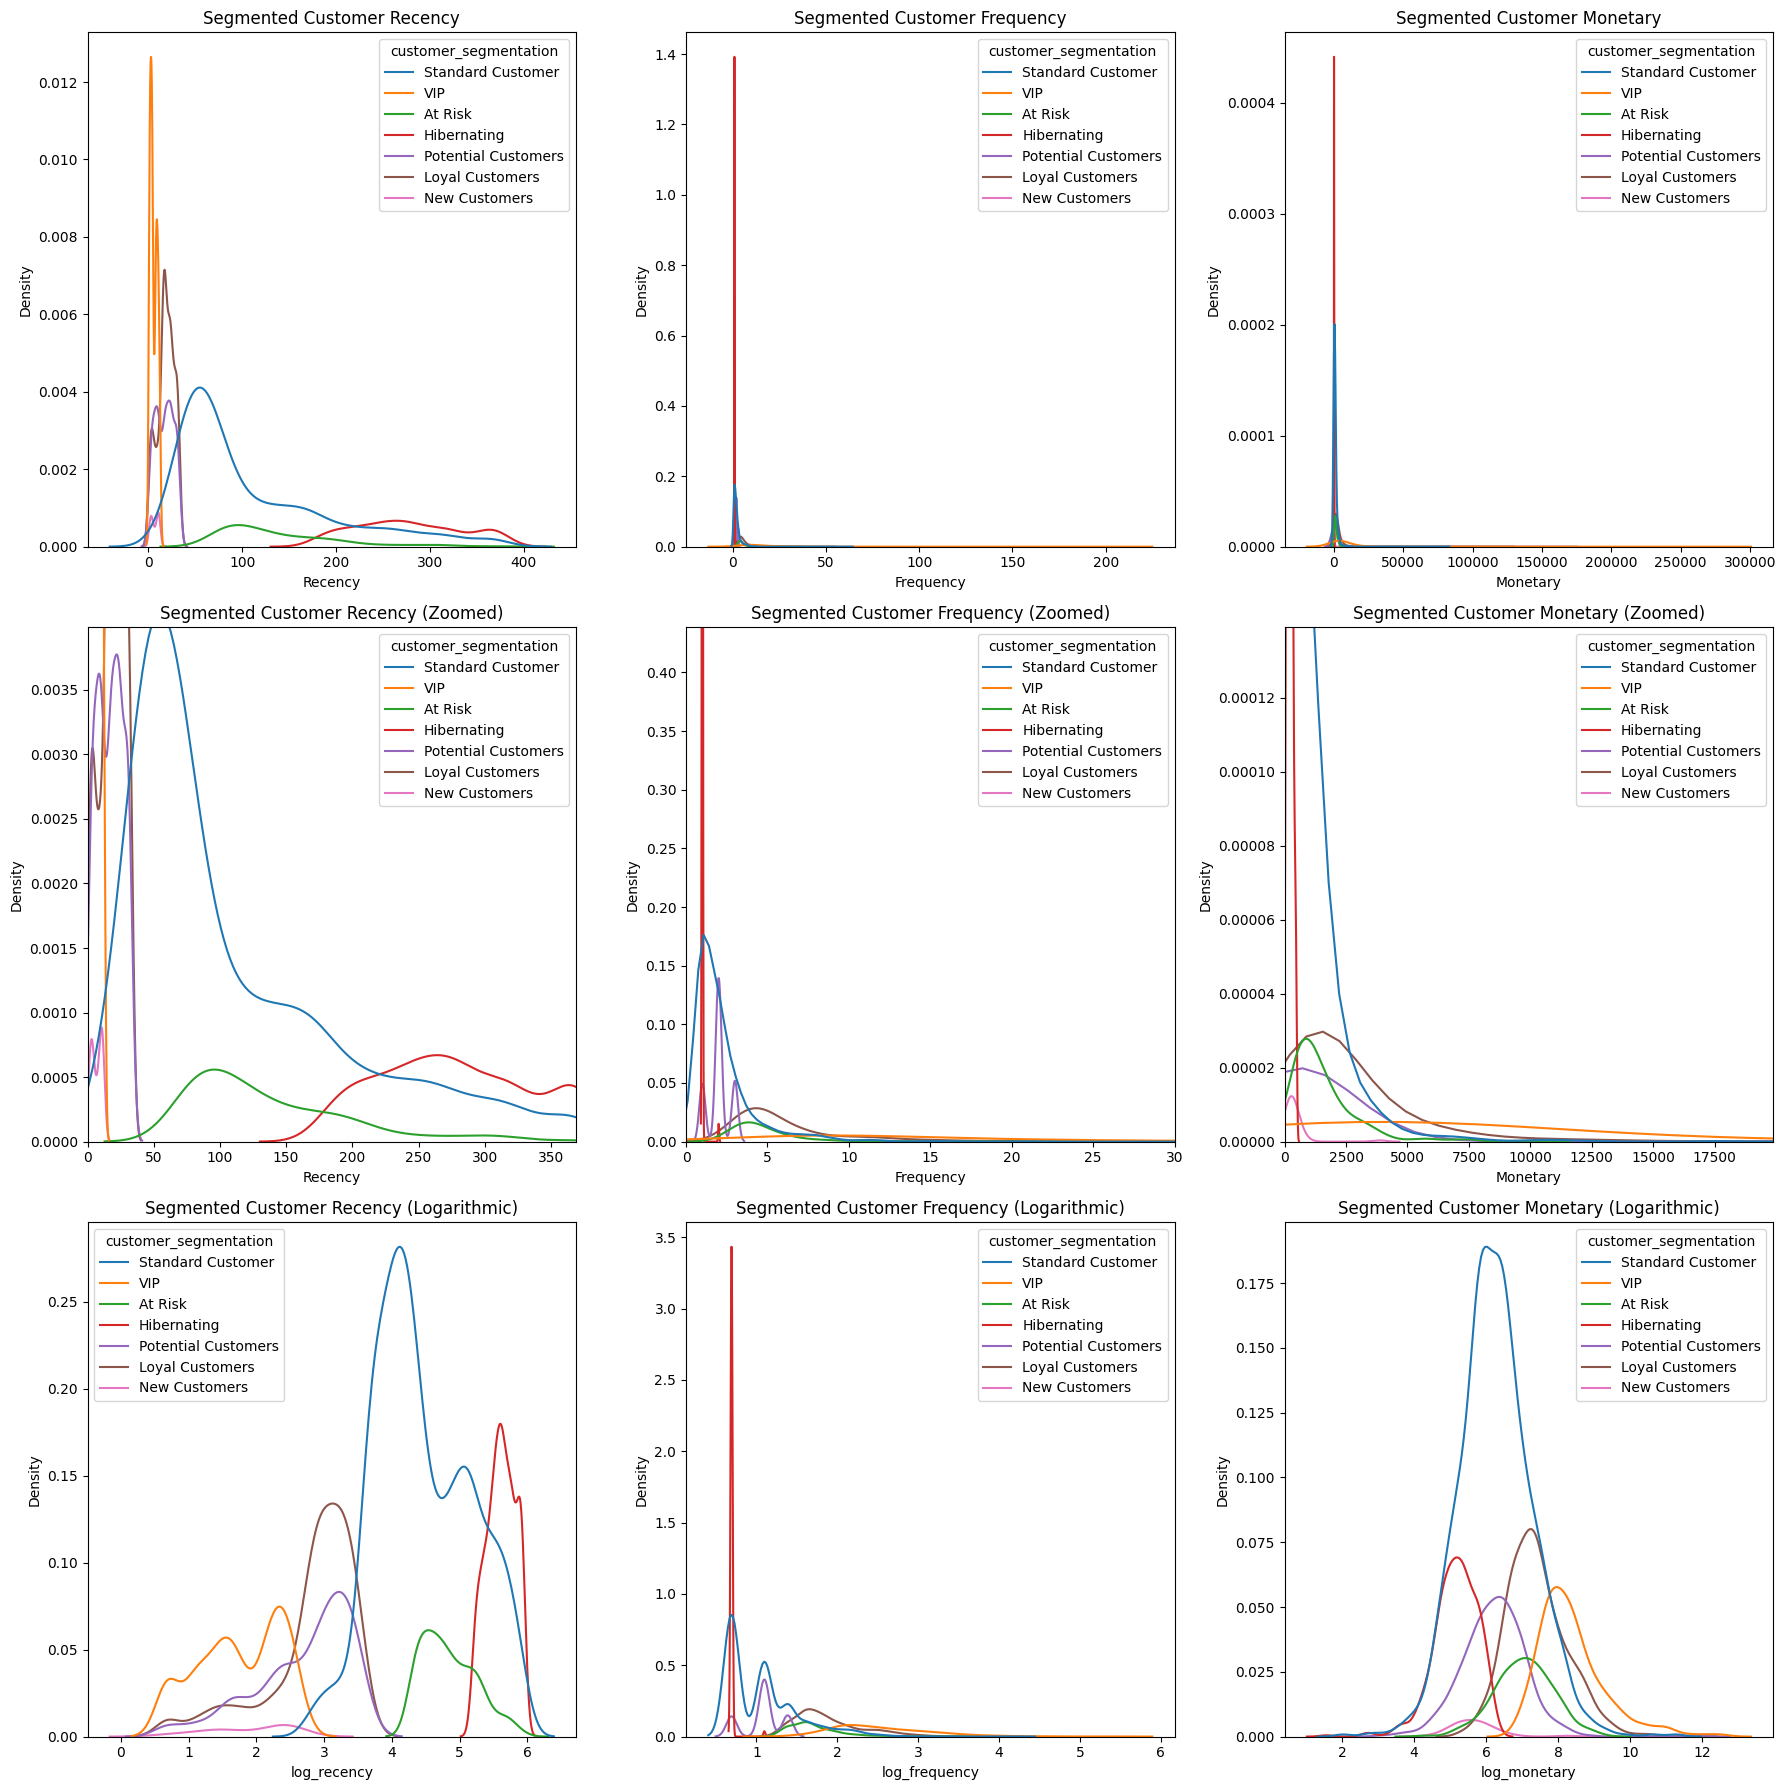

In [ ]:
# fig,axes = plt.subplots(3,3,figsize=(18,18))

# sns.kdeplot(data=df,x="Recency",hue="customer_segmentation",ax=axes[0,0]).set_title("Segmented Customer Recency")
# sns.kdeplot(data=df,x="Frequency",hue="customer_segmentation",ax=axes[0,1]).set_title("Segmented Customer Frequency")
# sns.kdeplot(data=df,x="Monetary",hue="customer_segmentation",ax=axes[0,2]).set_title("Segmented Customer Monetary")

# sns.kdeplot(data=df,x="Recency",hue="customer_segmentation",ax=axes[1,0]).set_title("Segmented Customer Recency (Zoomed)")
# sns.kdeplot(data=df,x="Frequency",hue="customer_segmentation",ax=axes[1,1]).set_title("Segmented Customer Frequency (Zoomed)")
# sns.kdeplot(data=df,x="Monetary",hue="customer_segmentation",ax=axes[1,2]).set_title("Segmented Customer Monetary (Zoomed)")

# sns.kdeplot(data=df,x="log_recency",hue="customer_segmentation",ax=axes[2,0]).set_title("Segmented Customer Recency (Logarithmic)")
# sns.kdeplot(data=df,x="log_frequency",hue="customer_segmentation",ax=axes[2,1]).set_title("Segmented Customer Frequency (Logarithmic)")
# sns.kdeplot(data=df,x="log_monetary",hue="customer_segmentation",ax=axes[2,2]).set_title("Segmented Customer Monetary (Logarithmic)")

# axes[1,0].set_xlim(0,df["Recency"].quantile(0.99))
# axes[1,1].set_xlim(0,df["Frequency"].quantile(0.99))
# axes[1,2].set_xlim(0,df["Monetary"].quantile(0.99))

# for ax in axes[1].flat:
#     ymin,ymax = ax.get_ylim()
#     ax.set_ylim(ymin,ymax*0.3)

# plt.tight_layout()
# plt.show()

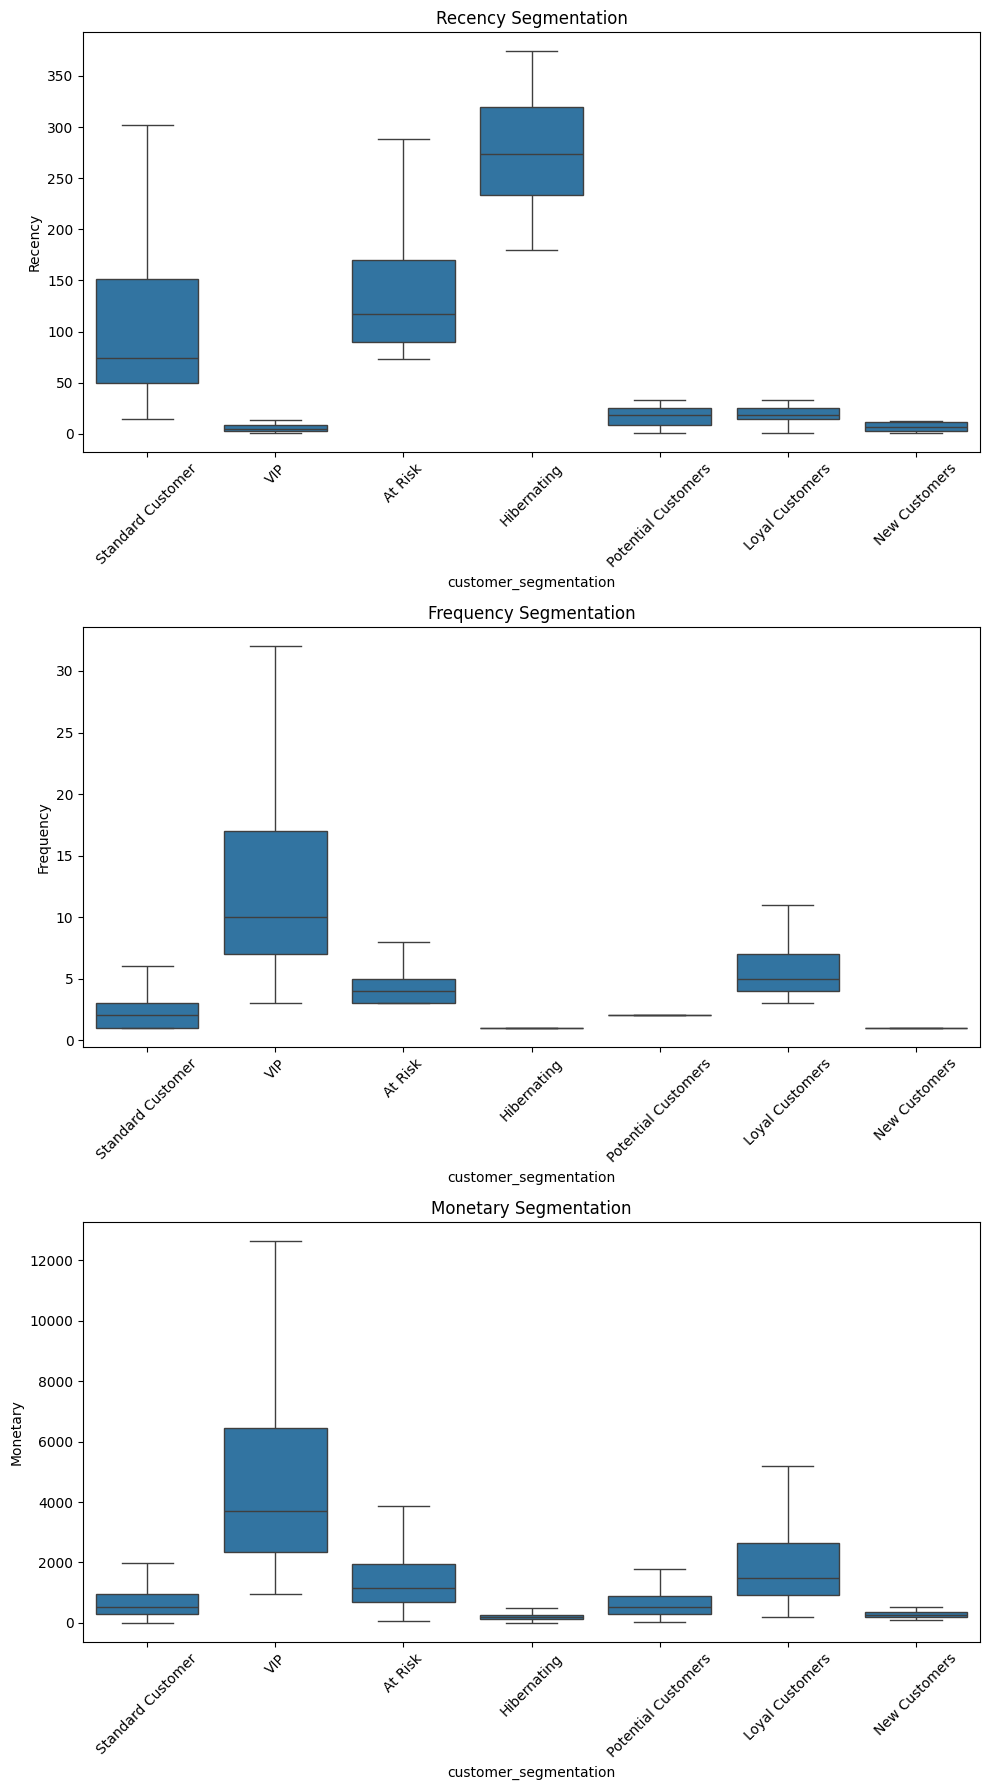

In [120]:
fig,axes = plt.subplots(3,1,figsize=(10,18))

sns.boxplot(data=df,x="customer_segmentation",y="Recency",ax=axes[0],showfliers=False).set_title("Recency Segmentation")
sns.boxplot(data=df,x="customer_segmentation",y="Frequency",ax=axes[1],showfliers=False).set_title("Frequency Segmentation")
sns.boxplot(data=df,x="customer_segmentation",y="Monetary",ax=axes[2],showfliers=False).set_title("Monetary Segmentation")

for ax in axes.flat:
    ax.tick_params(axis="x",rotation=45)

plt.tight_layout()
plt.show()

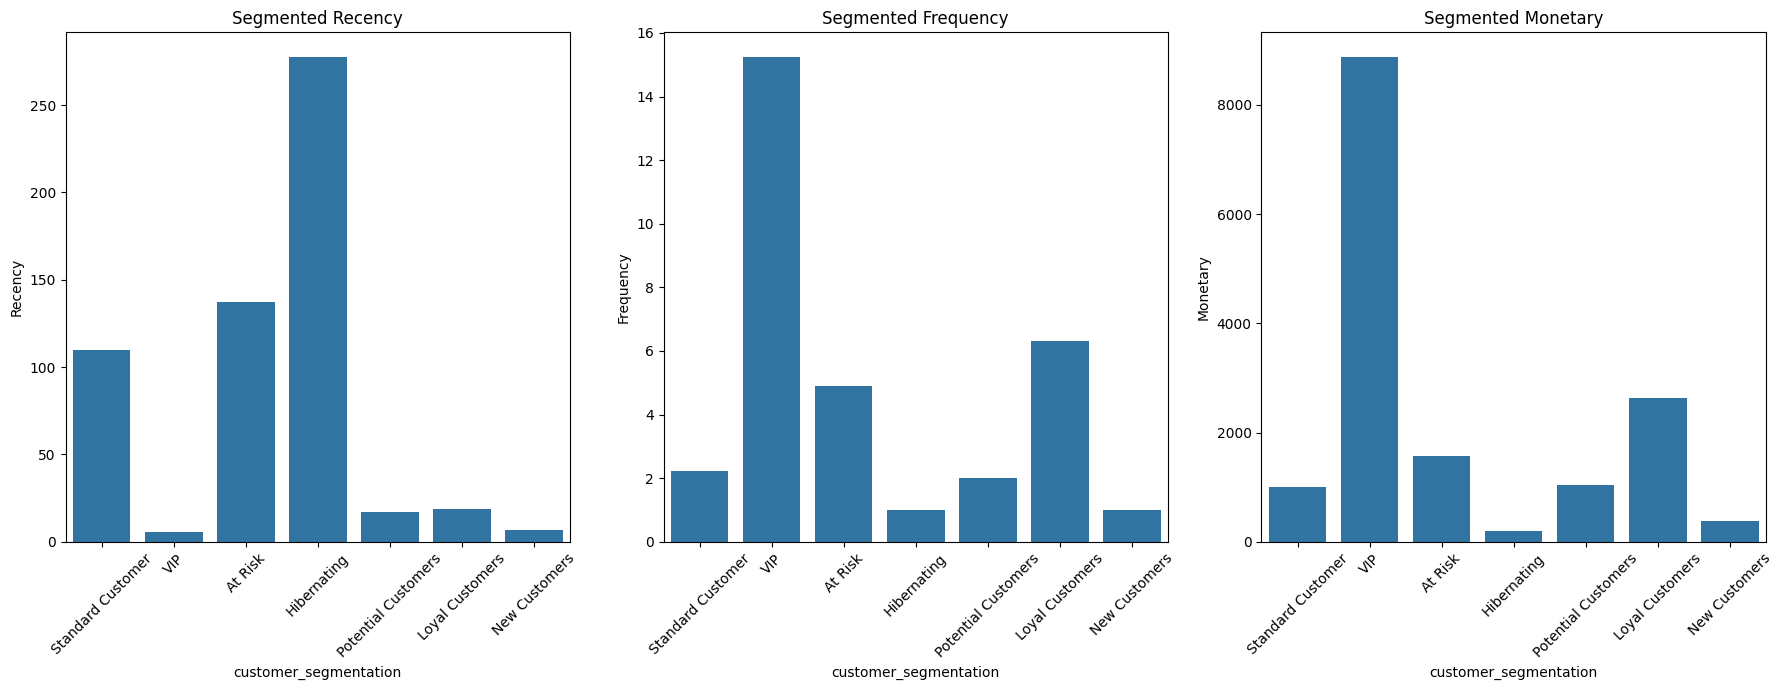

In [112]:
fig,axes = plt.subplots(1,3,figsize=(18,7))
sns.barplot(data=df,y="Recency",x="customer_segmentation",ax=axes[0],errorbar=None).set_title("Segmented Recency")
sns.barplot(data=df,y="Frequency",x="customer_segmentation",ax=axes[1],errorbar=None).set_title("Segmented Frequency")
sns.barplot(data=df,y="Monetary",x="customer_segmentation",ax=axes[2],errorbar=None).set_title("Segmented Monetary")

for ax in axes.flat:
    ax.tick_params(axis="x",rotation=45)

plt.tight_layout()

plt.show()

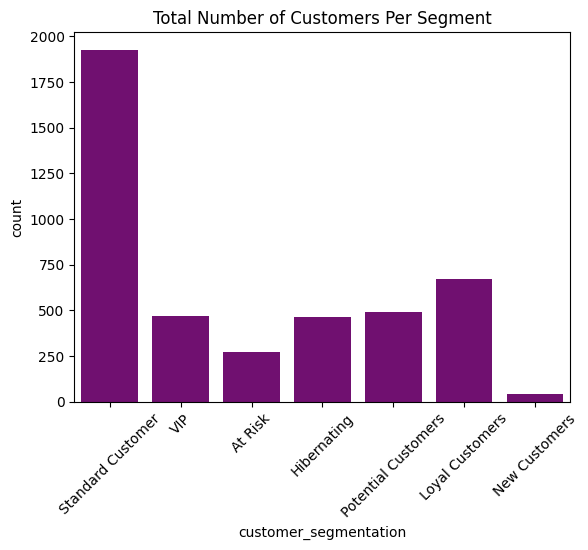

In [118]:
sns.countplot(data=df,x="customer_segmentation",color="Purple")
plt.title("Total Number of Customers Per Segment")
plt.xticks(rotation=45)
plt.show()

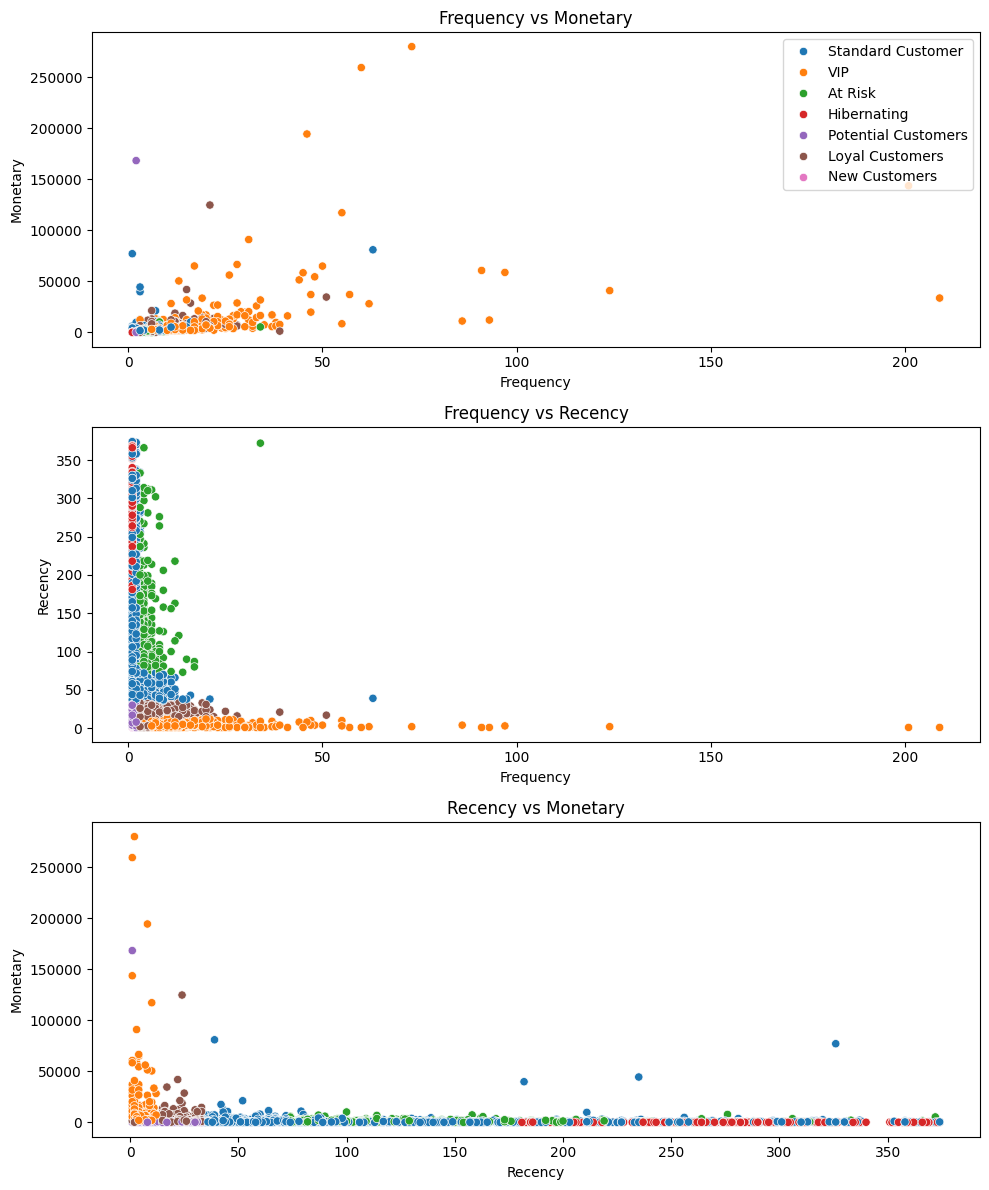

In [122]:
fig,axes = plt.subplots(3,1,figsize=(10,12))
sns.scatterplot(data=df,x="Frequency",y="Monetary",hue="customer_segmentation",ax=axes[0]).set_title("Frequency vs Monetary")
sns.scatterplot(data=df,x="Frequency",y="Recency",hue="customer_segmentation",ax=axes[1],legend=False).set_title("Frequency vs Recency")
sns.scatterplot(data=df,x="Recency",y="Monetary",hue="customer_segmentation",ax=axes[2],legend=False).set_title("Recency vs Monetary")

axes[0].legend(loc="upper right")

plt.tight_layout()
plt.show()